# Internal walkthrough of `split_area` and `split_points`

This notebook is not customer-facing. It is a developer guide to understand the
runtime behavior of the splitter logic in
`openeo.extra.job_management._job_splitting`.

It is configured to import from the local repository checkout (workspace source),
not from any preinstalled `openeo` package.

What this notebook covers:

1. `split_area` size-based path and custom-grid path.
2. `split_points` default quadtree path.
3. Quadtree no-progress fallback (coincident points -> plain chunking).
4. Row semantics (`Point` vs `MultiPoint` rows).
5. Tile-grid path (`gpd.sjoin`) with boundary and unmatched-point behavior.
6. CRS reprojection behavior in tile-grid mode.
7. Validation error cases.

All cells are safe to run locally without connecting to an openEO backend.

In [22]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry

# Force imports to come from this local repository checkout, not a preinstalled package.
repo_root = Path.cwd().resolve()
while not (repo_root / "openeo").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

if not (repo_root / "openeo").exists():
    raise RuntimeError("Could not locate local repository root containing 'openeo/'")

repo_root_str = str(repo_root)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

import openeo
from openeo.extra.job_management import split_area, split_points
from openeo.extra.job_management._job_splitting import JobSplittingFailure

print("Using local openeo from:", Path(openeo.__file__).resolve())

plt.rcParams["figure.figsize"] = (7, 6)


def plot_groups(groups, title, ax=None, markersize=20):
    if ax is None:
        fig, ax = plt.subplots()
    cmap = plt.get_cmap("tab20")
    for i, group in enumerate(groups):
        group.plot(ax=ax, color=cmap(i % 20), markersize=markersize, label=f"g{i} (n={len(group)})")
    ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    return ax


def print_group_sizes(groups, label):
    print(f"{label}: {len(groups)} groups")
    print("sizes:", [len(g) for g in groups])

Using local openeo from: C:\Git_projects\openeo-python-client\openeo\__init__.py


## Case 1: `split_area` size-based path

This follows the `split_area(..., projection=..., tile_size=...)` branch.
The AOI is reprojected to the tiling CRS and split into square tiles.

In [23]:
aoi = {"west": 3.60, "south": 51.0, "east": 3.80, "north": 51.12, "crs": "EPSG:4326"}

tiles = split_area(aoi=aoi, tile_size=5_000, projection="EPSG:3857")
print("tile CRS:", tiles.crs)
print("tile count:", len(tiles))
tiles.head()

tile CRS: EPSG:3857
tile count: 25


,geometry
0,"POLYGON ((405750.167 6621293.723, 405750.167 6..."
1,"POLYGON ((405750.167 6626293.723, 405750.167 6..."
2,"POLYGON ((405750.167 6631293.723, 405750.167 6..."
3,"POLYGON ((405750.167 6636293.723, 405750.167 6..."
4,"POLYGON ((405750.167 6641293.723, 405750.167 6..."


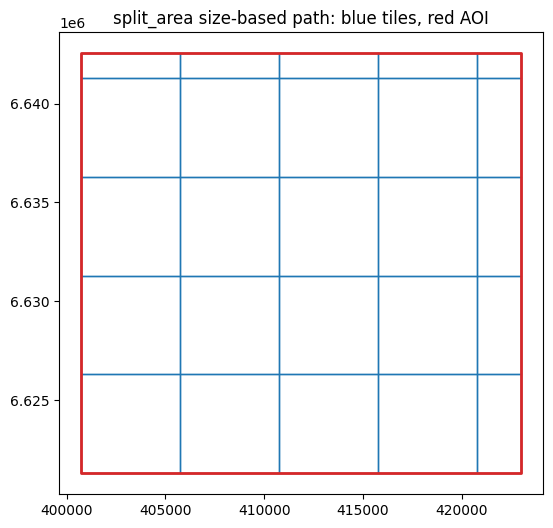

In [24]:
ax = tiles.plot(facecolor="none", edgecolor="tab:blue")
aoi_poly = shapely.geometry.box(aoi["west"], aoi["south"], aoi["east"], aoi["north"])
aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_poly], crs="EPSG:4326")
aoi_gdf.to_crs(tiles.crs).plot(ax=ax, facecolor="none", edgecolor="tab:red", linewidth=2)
ax.set_title("split_area size-based path: blue tiles, red AOI")
plt.show()

## Case 2: `split_points` default quadtree path

This follows the `tile_grid is None` branch:

- centroids are computed
- recursive quadtree split is applied
- groups are capped by `max_points`

In [32]:
rng = np.random.default_rng(42)

cluster_a = rng.normal(loc=(3.65, 51.03), scale=0.01, size=(150, 2))
cluster_b = rng.normal(loc=(3.75, 51.09), scale=0.01, size=(150, 2))
coords = np.vstack([cluster_a, cluster_b])

points = gpd.GeoDataFrame(
    geometry=[shapely.geometry.Point(xy) for xy in coords],
    crs="EPSG:4326",
)

groups = split_points(points, max_points=100)
print("input rows:", len(points))
print_group_sizes(groups, "default quadtree")

input rows: 300
default quadtree: 8 groups
sizes: [63, 38, 28, 21, 32, 24, 43, 51]


C:\Git_projects\openeo-python-client\openeo\extra\job_management\_job_splitting.py:481: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = points.geometry.centroid


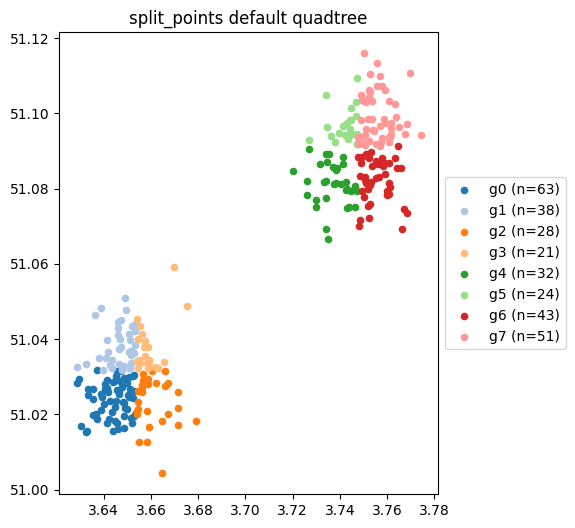

In [33]:
plot_groups(groups, "split_points default quadtree")
plt.show()

## Case 3: tile-grid path (`gpd.sjoin`) and why `centroids_gdf` matters

This follows the `tile_grid is not None` branch:

- use centroid geometries (`centroids_gdf`)
- optional CRS reprojection of centroids to tile-grid CRS
- spatial join: each centroid gets a matching tile (`index_right`)
- de-duplicate centroids that match multiple tiles on boundaries
- split each tile group separately

We will inspect the join table directly before calling `split_points`.

In [34]:
# Reuse 'tiles' from Case 1 (EPSG:3857)
points_3857 = points.to_crs(tiles.crs)
centroids_gdf = gpd.GeoDataFrame(geometry=points_3857.geometry.centroid, crs=points_3857.crs)

joined = gpd.sjoin(
    centroids_gdf,
    tiles[["geometry"]].reset_index(drop=True),
    how="left",
    predicate="intersects",
)

print("joined rows:", len(joined))
print("input rows:", len(points_3857))
print("rows with no tile match (index_right is NaN):", joined["index_right"].isna().sum())
joined.head()

joined rows: 300
input rows: 300
rows with no tile match (index_right is NaN): 0


,geometry,index_right
0,POINT (406655.351 6624761.497),5
1,POINT (407151.54 6628267.088),6
2,POINT (404144.259 6624297.52),0
3,POINT (406458.453 6626042.353),5
4,POINT (406297.438 6625092.318),5


### Debug view: centroid-to-tile assignment before splitting

This plot visualizes the exact `gpd.sjoin` output used by the tile-grid branch:

- each centroid is colored by `index_right` (the matched tile index)
- centroids with no tile match are highlighted separately

If this looks wrong, the resulting split groups will also be wrong.

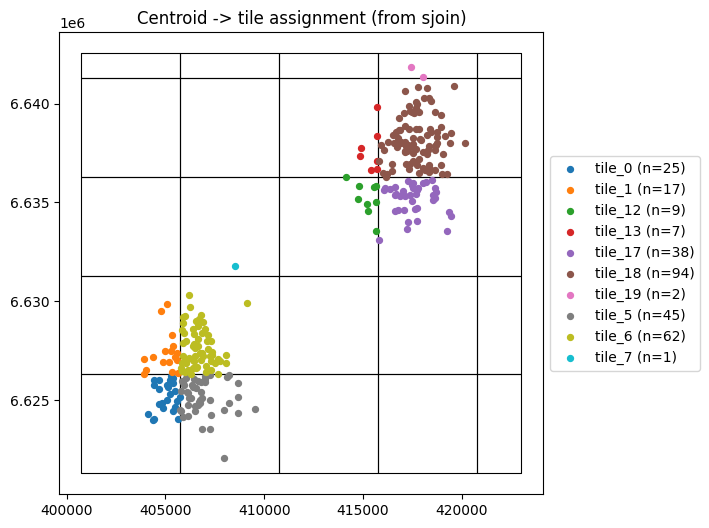

In [35]:
# Visual check of tile assignment from sjoin (`index_right`)
joined_plot = joined.copy()
joined_plot["tile_label"] = joined_plot["index_right"].apply(
    lambda v: "unmatched" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"tile_{int(v)}"
)

ax = tiles.plot(facecolor="none", edgecolor="black", linewidth=0.8)

for label, sub in joined_plot.groupby("tile_label"):
    color = "red" if label == "unmatched" else None
    sub.plot(ax=ax, markersize=18, label=f"{label} (n={len(sub)})", color=color)

ax.set_title("Centroid -> tile assignment (from sjoin)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

tile-grid split: 16 groups
sizes: [25, 17, 45, 39, 16, 6, 1, 1, 9, 7, 38, 40, 18, 27, 9, 2]


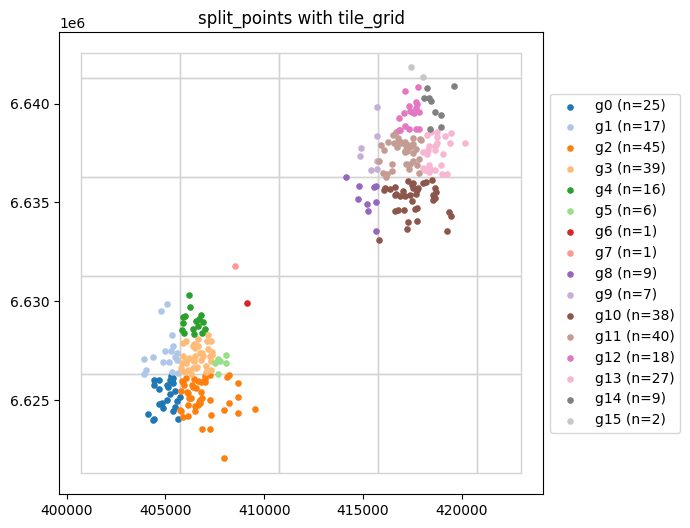

In [36]:
tile_groups = split_points(points_3857, max_points=50, tile_grid=tiles)
print_group_sizes(tile_groups, "tile-grid split")

ax = tiles.plot(facecolor="none", edgecolor="lightgrey")
plot_groups(tile_groups, "split_points with tile_grid", ax=ax, markersize=14)
plt.show()

## Case 4: quadtree no-progress fallback (`any(len(q) == len(idx))`)

When all points coincide (or all land in one quadrant), recursive quartering
cannot reduce the set size. The implementation then falls back to plain
chunking by `max_points` to guarantee termination.

In [37]:
coincident = gpd.GeoDataFrame(
    geometry=[shapely.geometry.Point(0, 0)] * 25,
    crs="EPSG:4326",
)
coincident_groups = split_points(coincident, max_points=10)
print_group_sizes(coincident_groups, "coincident fallback")

coincident fallback: 3 groups
sizes: [10, 10, 5]


C:\Git_projects\openeo-python-client\openeo\extra\job_management\_job_splitting.py:481: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = points.geometry.centroid


## Case 5: row semantics (`Point` and `MultiPoint`)

`split_points` counts rows (features), not embedded coordinates.
A single `MultiPoint` row is still one feature for `max_points`.

In [38]:
mixed = gpd.GeoDataFrame(
    geometry=[
        shapely.geometry.MultiPoint([(0, 0), (0.1, 0.1), (0.2, 0.2)]),
        shapely.geometry.Point(0.5, 0.5),
    ],
    crs="EPSG:4326",
)
mixed_groups = split_points(mixed, max_points=10)
print("row count:", len(mixed))
print("group row counts:", [len(g) for g in mixed_groups])

row count: 2
group row counts: [2]


C:\Git_projects\openeo-python-client\openeo\extra\job_management\_job_splitting.py:481: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = points.geometry.centroid


## Case 6: centroid on shared tile boundary (duplicate join rows)

A point exactly on a shared edge can intersect more than one tile, producing
multiple rows in `sjoin`. The implementation then keeps only the first match
for that centroid index.

In [39]:
boundary_tiles = gpd.GeoDataFrame(
    geometry=[
        shapely.geometry.box(0, 0, 1, 1),
        shapely.geometry.box(1, 0, 2, 1),
    ],
    crs="EPSG:4326",
)

boundary_points = gpd.GeoDataFrame(
    geometry=[
        shapely.geometry.Point(1, 0.5),  # exactly on shared boundary x=1
        shapely.geometry.Point(0.5, 0.5),
    ],
    crs="EPSG:4326",
)

raw_join = gpd.sjoin(
    gpd.GeoDataFrame(geometry=boundary_points.geometry.centroid, crs=boundary_points.crs),
    boundary_tiles[["geometry"]].reset_index(drop=True),
    how="left",
    predicate="intersects",
)

print("raw sjoin rows:", len(raw_join))
print(raw_join)
print("rows after dedup-by-left-index:", len(raw_join.loc[~raw_join.index.duplicated(keep="first")]))

raw sjoin rows: 3
          geometry  index_right
0    POINT (1 0.5)            0
0    POINT (1 0.5)            1
1  POINT (0.5 0.5)            0
rows after dedup-by-left-index: 2


C:\Users\VROMPAYH\AppData\Local\Temp\ipykernel_31420\1828992808.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gpd.GeoDataFrame(geometry=boundary_points.geometry.centroid, crs=boundary_points.crs),


## Case 7: unmatched points (`index_right = NaN`) and CRS reprojection

This demonstrates two behaviors:

- points outside all tiles are still kept (left join) and split separately
- when point CRS differs from tile-grid CRS, centroids are reprojected before
  the spatial join

In [40]:
# Tile grid in EPSG:3857
wm_tile_grid = gpd.GeoDataFrame(
    geometry=[shapely.geometry.box(-111_320, -111_325, 111_320, 111_325)],
    crs="EPSG:3857",
)

# Points in EPSG:4326 (one near origin, one far away)
points_wgs84 = gpd.GeoDataFrame(
    geometry=[shapely.geometry.Point(0.1, 0.1), shapely.geometry.Point(50, 50)],
    crs="EPSG:4326",
)

mixed_groups = split_points(points_wgs84, max_points=10, tile_grid=wm_tile_grid)
print_group_sizes(mixed_groups, "CRS mismatch + unmatched point")
for i, g in enumerate(mixed_groups):
    print(f"group {i} bounds:", g.total_bounds)

C:\Git_projects\openeo-python-client\openeo\extra\job_management\_job_splitting.py:481: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = points.geometry.centroid


ValueError: Categorical categories cannot be null

## Case 8: validation errors (guard clauses)

These are the explicit checks in `split_points` and `split_area`.
Run this cell to see the exact exceptions raised by invalid inputs.

In [41]:
def show_error(label, fn):
    try:
        fn()
    except Exception as e:
        print(f"[{label}] {type(e).__name__}: {e}")

show_error(
    "split_points missing geometry column",
    lambda: split_points(gpd.GeoDataFrame({"foo": [1, 2]})),
)

show_error(
    "split_points missing CRS",
    lambda: split_points(gpd.GeoDataFrame(geometry=[shapely.geometry.Point(0, 0)])),
)

show_error(
    "split_points non-positive max_points",
    lambda: split_points(gpd.GeoDataFrame(geometry=[shapely.geometry.Point(0, 0)], crs="EPSG:4326"), max_points=0),
)

show_error(
    "split_points tile_grid missing CRS",
    lambda: split_points(
        gpd.GeoDataFrame(geometry=[shapely.geometry.Point(0, 0)], crs="EPSG:4326"),
        tile_grid=gpd.GeoDataFrame(geometry=[shapely.geometry.box(0, 0, 1, 1)]),
    ),
)

show_error(
    "split_area conflicting args",
    lambda: split_area(
        shapely.geometry.box(0, 0, 1, 1),
        projection="EPSG:4326",
        tile_size=1.0,
        tile_grid=gpd.GeoDataFrame(geometry=[shapely.geometry.box(0, 0, 1, 1)], crs="EPSG:4326"),
    ),
)

show_error(
    "split_area missing projection",
    lambda: split_area({"west": 0.0, "south": 0.0, "east": 1.0, "north": 1.0, "crs": "EPSG:4326"}, tile_size=1.0),
)

show_error(
    "split_area invalid AOI type",
    lambda: split_area("not_a_geometry", projection="EPSG:4326", tile_size=1.0),
)

[split_points missing geometry column] JobSplittingFailure: The GeoDataFrame must contain a 'geometry' column.
[split_points missing CRS] JobSplittingFailure: The GeoDataFrame must have a CRS set.
[split_points non-positive max_points] JobSplittingFailure: 'max_points' must be positive, got 0.
[split_points tile_grid missing CRS] JobSplittingFailure: The 'tile_grid' GeoDataFrame must have a CRS set.
[split_area conflicting args] JobSplittingFailure: Cannot combine 'tile_grid' with 'projection' or 'tile_size'. Either pass a _TileGridInterface, or pass projection + tile_size.
[split_area missing projection] JobSplittingFailure: 'projection' is required when using size-based tiling.
[split_area invalid AOI type] JobSplittingFailure: Expected a bounding-box dict, Polygon, or MultiPolygon, got str.
